In [1]:
import numpy as np
import scipy as sp
import krylov as kr
import ham_generator as gen
import matplotlib.pyplot as plt
import networkx as nx

INITIAL STATE IS ALWAYS LOCALIZED

# Testing of numerical computation of Complexity against analytically solved examples

## Real Hamiltonians: adjacency matrices corresponding to different topologies

### Complete graph
The complexity of a complete graph of dimension $d$ is: $$ \bar{\mathcal{C}} = \frac{2(d-1)}{d^2} $$ 

In [2]:
#returns the analytical time averaged complexity for a complete graph with adjacency matrix
def analytic_compl_adj(dim):
    return 2.*(dim-1)/dim**2

In [3]:
d_max = 30
an_x = np.linspace(3, d_max, d_max-2, dtype=int)
an_y = analytic_compl_adj(an_x)

compl = np.zeros(an_x.shape)
for i in an_x:
    H = gen.adjacency_matrix(nx.complete_graph(i))
    initial = np.zeros(i, dtype=complex)
    initial[0] = 1.0+0.j
    #initial = np.ones(i, dtype=complex)
    new_H, compl[i-3] = kr.get_complexity(H, initial)

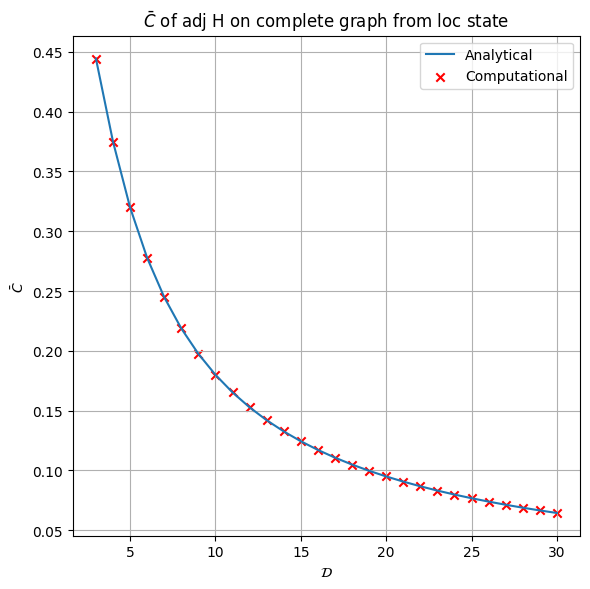

In [4]:
fig, axx = plt.subplots(1,1, figsize=(6,6), tight_layout=True)

axx.grid(True)
axx.plot(an_x,an_y, label="Analytical")
axx.scatter(an_x, compl, label="Computational", marker="x", color="r")
axx.set_title(r"$\bar{C}$ of adj H on complete graph from loc state")
axx.set_ylabel(r"$\bar{C}$")
axx.set_xlabel(r"$\mathcal{D}$")
axx.legend()
plt.show()

### Path Graph
Complexity: $$ \bar{\mathcal{C}} = \frac{d-1}{2} $$ 

In [5]:
d_max = 30
an_x = np.linspace(3, d_max, d_max-2, dtype=int)
an_y_chain = (an_x-1.)/2.

compl_chain = np.zeros(an_x.shape)
for i in an_x:
    H_chain = gen.adjacency_matrix(nx.path_graph(i))
    initial = np.zeros(i, dtype=complex)
    initial[0] = 1.0+0.j
    #initial = np.ones(i, dtype=complex)
    new_H, compl_chain[i-3] = kr.get_complexity(H_chain, initial)

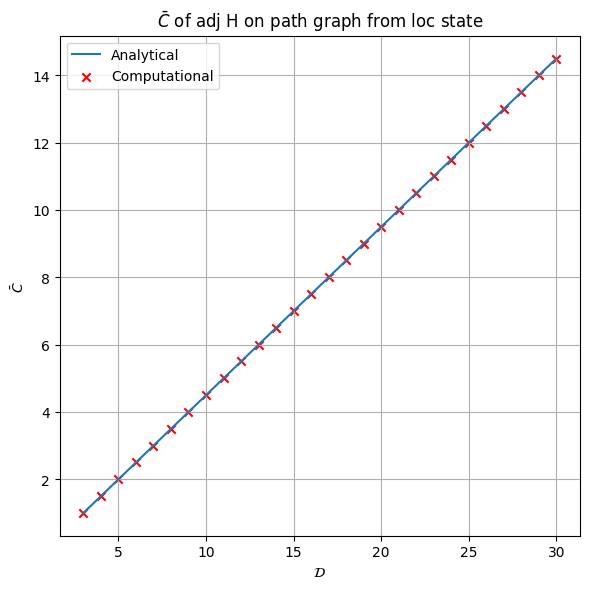

In [6]:
fig, axx = plt.subplots(1,1, figsize=(6,6), tight_layout=True)

axx.grid(True)
axx.plot(an_x,an_y_chain, label="Analytical")
axx.scatter(an_x, compl_chain, label="Computational", marker="x", color="r")
#axx.plot(an_x, np.abs(an_y_chain-compl_chain))
axx.set_title(r"$\bar{C}$ of adj H on path graph from loc state")
axx.set_ylabel(r"$\bar{C}$")
axx.set_xlabel(r"$\mathcal{D}$")
axx.legend()
plt.show()

### Loop Graph

Complexity
* for $d$ even: $$ \bar{\mathcal{C}} = \frac{d}{4} $$ 
* for $d$ odd: $$ \bar{\mathcal{C}} = \frac{d^2-1}{4d^2}(d-1) $$

In [7]:
d_max = 50
an_x = np.linspace(3, d_max, d_max-2, dtype=int)
an_y_cycle_even = an_x/4.
an_y_cycle_odd = (an_x**2-1.)*(an_x-1.)/(4.*an_x**2)

compl_cycle = np.zeros(an_x.shape)
for i in an_x:
    H_cycle = gen.adjacency_matrix(nx.cycle_graph(i))
    initial = np.zeros(i, dtype=complex)
    initial[0] = 1.0+0.j
    #initial = np.ones(i, dtype=complex)
    new_H, compl_cycle[i-3] = kr.get_complexity(H_cycle, initial)

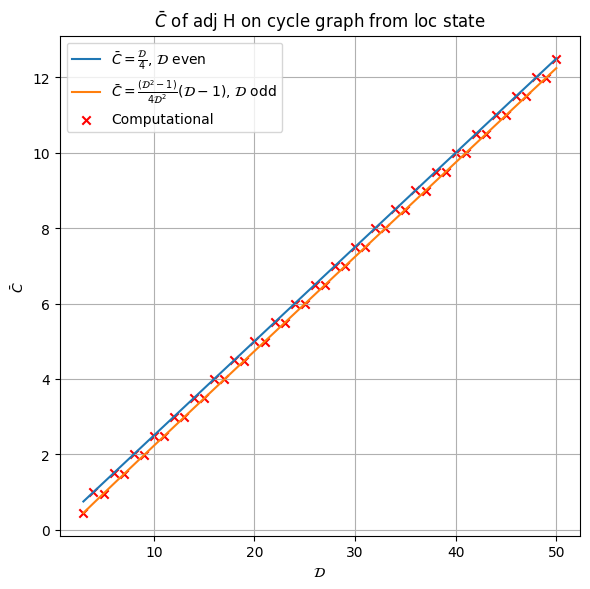

In [8]:
fig, axx = plt.subplots(1,1, figsize=(6,6), tight_layout=True)

axx.grid(True)
axx.plot(an_x,an_y_cycle_even, label=r"$\bar{C}=\frac{\mathcal{D}}{4}$, $\mathcal{D}$ even")
axx.plot(an_x,an_y_cycle_odd, label=r"$\bar{C}=\frac{(\mathcal{D}^2-1)}{4\mathcal{D}^2}(\mathcal{D}-1)$, $\mathcal{D}$ odd")
axx.scatter(an_x, compl_cycle, label="Computational", marker="x", color="r")
axx.set_title(r"$\bar{C}$ of adj H on cycle graph from loc state")
axx.set_ylabel(r"$\bar{C}$")
axx.set_xlabel(r"$\mathcal{D}$")
axx.legend()
plt.show()

## Complex Hamiltonians: circulant cycle graphs

Each edge of the graph (now directed) is weighted with a phase $e^{i\varphi}$.

The complexity in terms of the dimension is: $$ \bar{\mathcal{C}} = \frac{d-1}{2} $$

In [9]:
d_max = 50
an_x = np.linspace(3, d_max, d_max-2, dtype=int)
an_y_circ_cycle = (an_x-1.)/2.

phase = np.pi/100
compl_circ_cycle = np.zeros(an_x.shape)
for i in an_x:
    H_circ_cycle = gen.circulant_cycle(i,phi=phase)
    initial = np.zeros(i, dtype=complex)
    initial[0] = 1.0+0.j
    #initial = np.ones(i, dtype=complex)
    new_H, compl_circ_cycle[i-3] = kr.get_complexity(H_circ_cycle, initial)

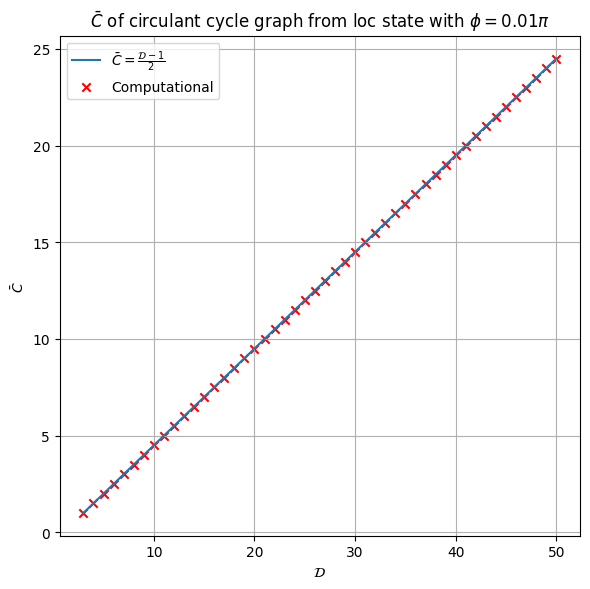

In [10]:
fig, axx = plt.subplots(1,1, figsize=(6,6), tight_layout=True)

axx.grid(True)
#axx.plot(an_x,an_y_cycle_even, label="Analytical even dim")
axx.plot(an_x,an_y_circ_cycle, label=r"$\bar{C}=\frac{\mathcal{D}-1}{2}$")
axx.scatter(an_x, compl_circ_cycle, label="Computational", marker="x", color="r")
axx.set_title(r"$\bar{C}$ of circulant cycle graph from loc state with"+f" $\phi=${phase/np.pi}$\pi$")
axx.set_ylabel(r"$\bar{C}$")
axx.set_xlabel(r"$\mathcal{D}$")
axx.legend()
plt.show()

# Consistency check: state localization in Anderson chain models

An Anderson chain is a chain graph with Hamiltonian $H = JA + D$, where $A$ is the adjacency matrix and $D$ is a diagonal matrix (in the site basis) with random entries uniformly distributed in $[-W,W]$, with $W$ being the disorder parameter. 

The hopping intensity constant $J$ can be set equal to 1, up to a rescaling of time. 

It is known that increasing values of $W$ give rise to exponentially localized eigenstates: this is reflected by the fact that the complexity of a dynamics starting from a localized state decreases as $W$ is increased.

In [11]:
#Eigenvalues of an ensemble of Anderson chains
def anderson_chain_ensemble(iterations, disorder, dim):
    eigens = np.ndarray(iterations)

    for i in range(iterations):
        rand = gen.Anderson_H(dim=dim, W=disorder)
        E= np.linalg.eigvalsh(rand)
        eigens[i] = E[0]
    
    return eigens

#Complexity of an ensemble of Anderson chains
def anderson_compl_ensemble(iterations, disorder, dim, initial):
    compl_ensemble = np.zeros(iterations)

    for i in range(iterations):
        rand = gen.Anderson_H(dim=dim, W=disorder)
        new_H, compl_ensemble[i] = kr.get_complexity(rand, initial)
    
    return compl_ensemble

In [12]:
disorders = np.linspace(start=0.1, stop=5., num=9)
iterations = 10000
dim = 10
compl_values = np.ndarray((disorders.size, iterations))

np.random.seed(0)
initial = np.zeros(dim, dtype=complex)
initial[0] = 1.0+0.j
for i in range(disorders.size):
    compl_values[i] = anderson_compl_ensemble(iterations=iterations, disorder=disorders[i], dim=dim, initial=initial)

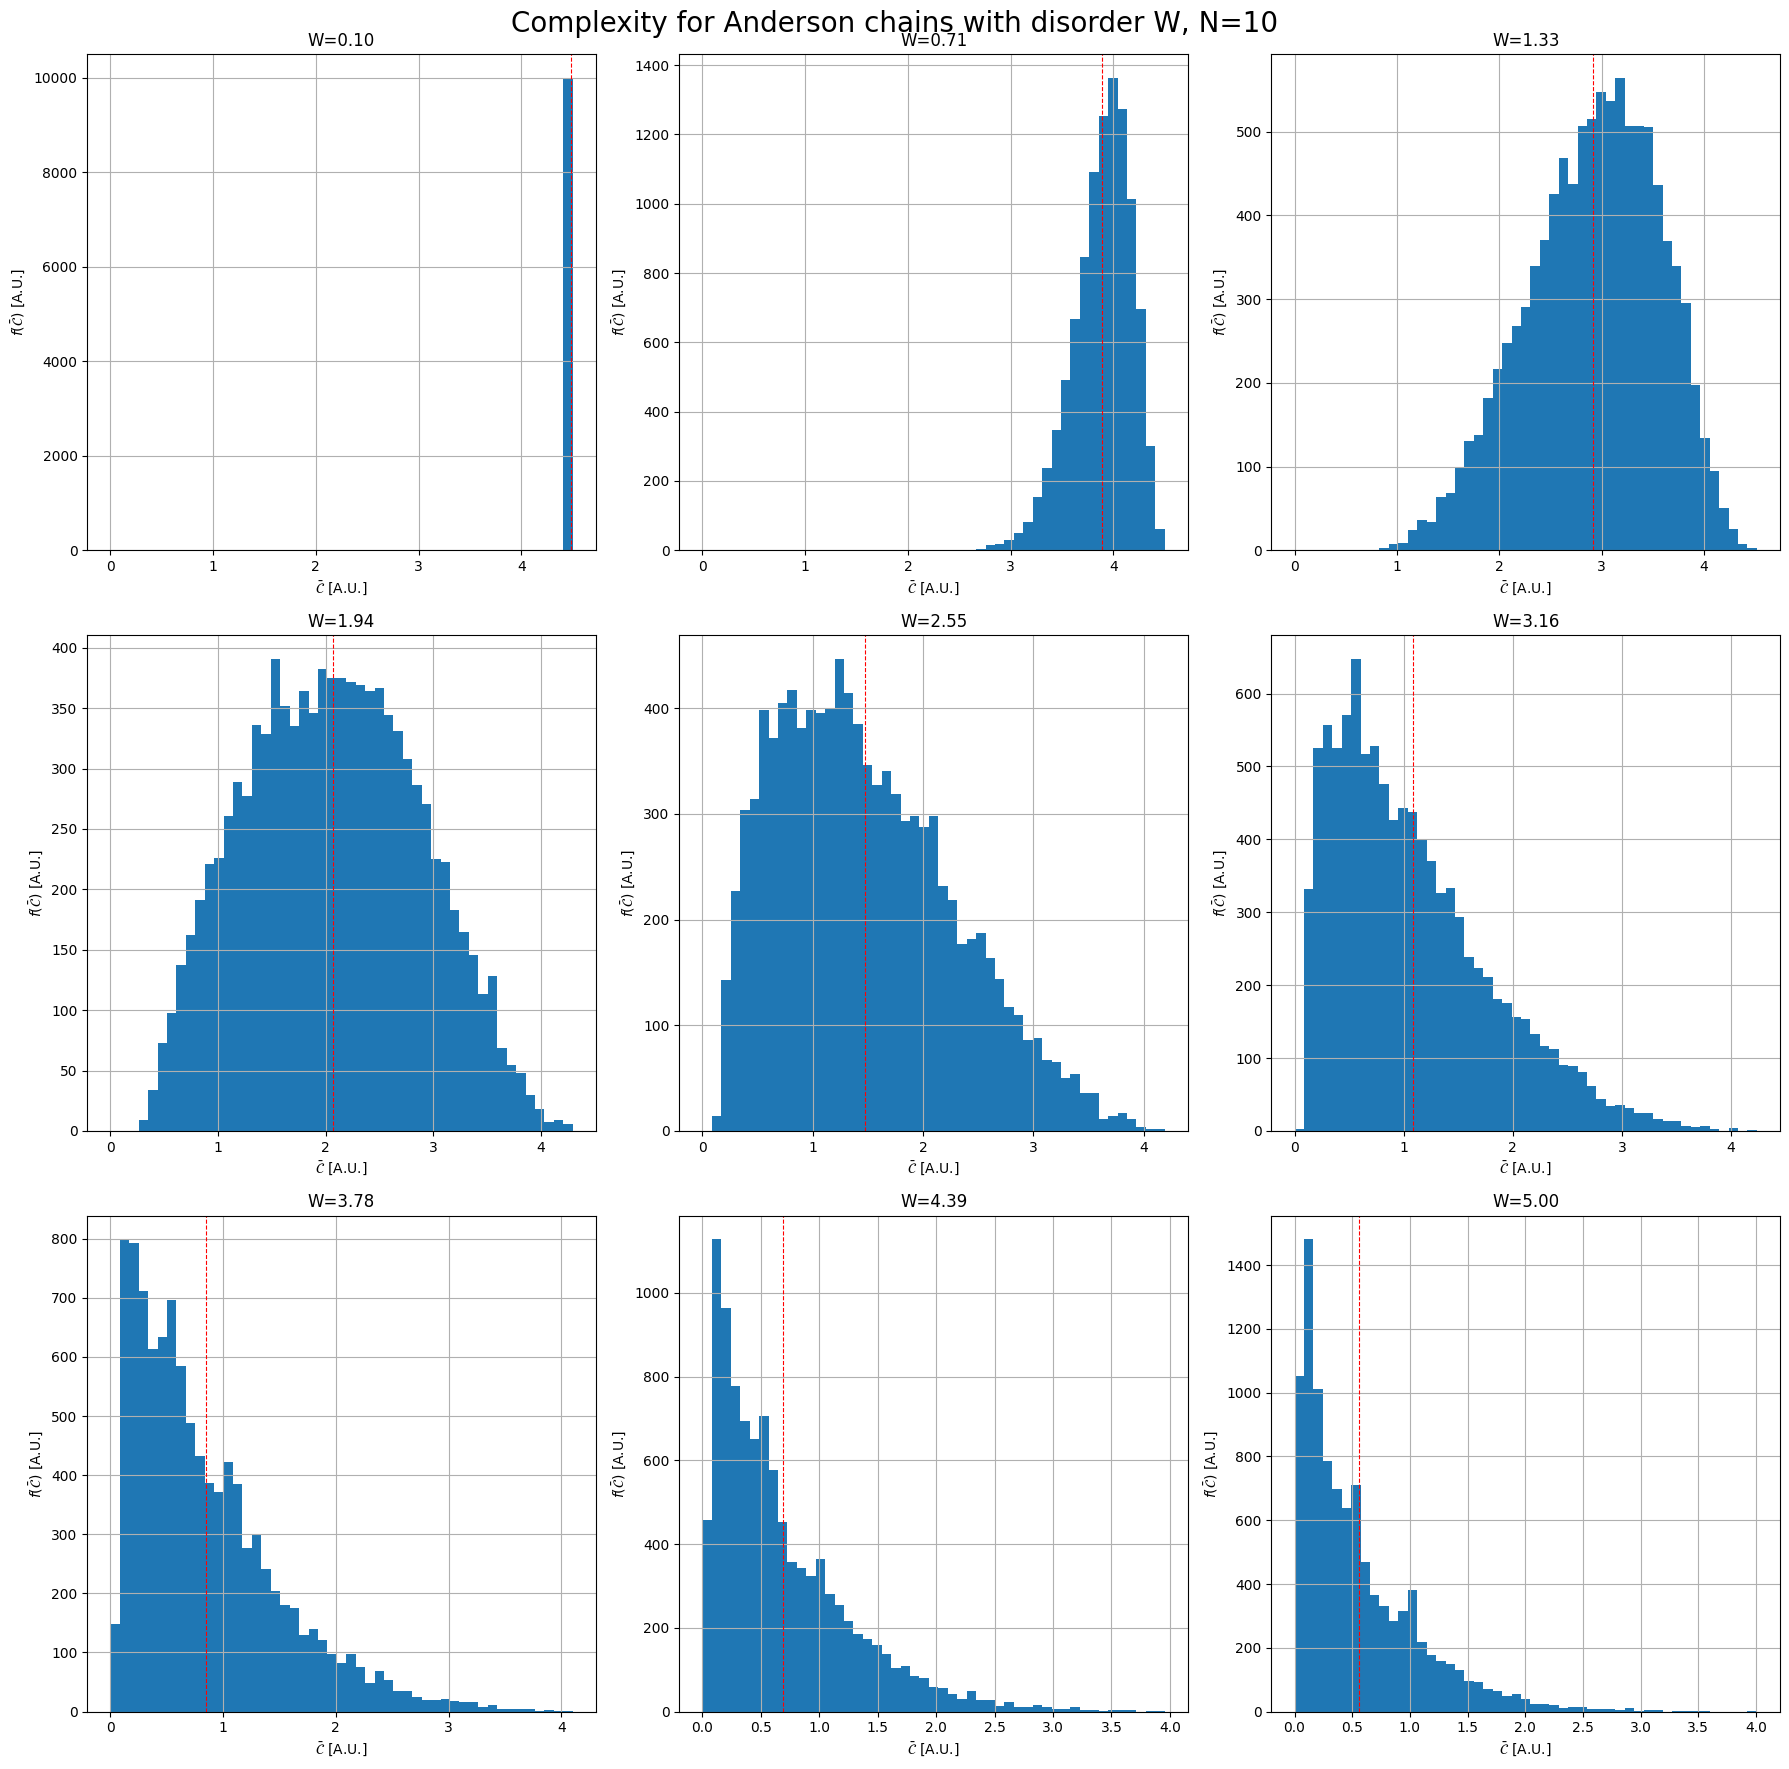

In [13]:
fig, axx = plt.subplots(3,3, figsize=(18,18), tight_layout=True)
fig.suptitle("Complexity for Anderson chains with disorder W, N="+f"{dim}", fontsize=20)
k = 0
for i in range(axx.shape[0]):
    for j in range(axx.shape[1]):
        compls = compl_values[k]
        n_bins = 50
        bins = np.linspace(start=0.,stop=compls.max(), num=n_bins)
        axx[i][j].grid(True)
        axx[i][j].hist(compls, bins=bins)
        axx[i][j].axvline(x=compls.mean(), linestyle='--', color='r', linewidth=0.8)
        axx[i][j].set_title(f"W={format(disorders[k],'.2f')}")
        axx[i][j].set_xlabel(r"$\bar{\mathcal{C}}$ [A.U.]")
        axx[i][j].set_ylabel(r"$f(\bar{\mathcal{C}})$ [A.U.]")
        k+=1
plt.show()

In [14]:
av = np.array([np.mean(compl_values[i]) for i in range(disorders.size)])

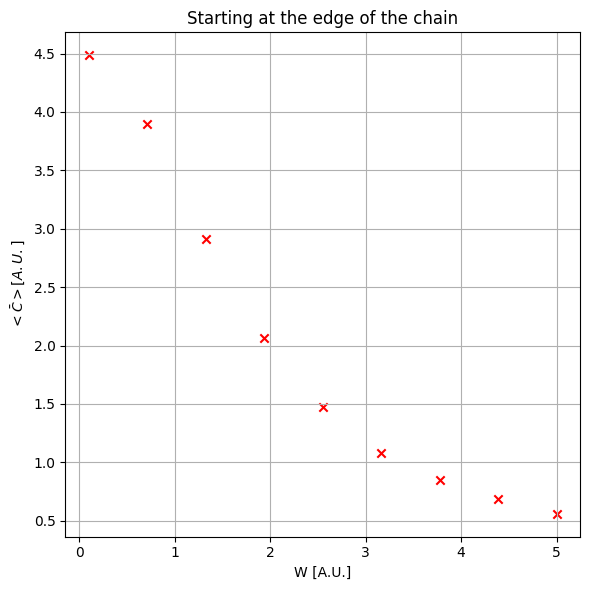

In [15]:
fig, axx = plt.subplots(1,1, figsize=(6,6), tight_layout=True)

axx.scatter(disorders, av, marker="x", color="r")
axx.set_xlabel("W [A.U.]")
axx.set_ylabel(r"$<\bar{C}> [A.U.]$")
axx.set_title("Starting at the edge of the chain")
axx.grid(True)

In [16]:
disorders = np.linspace(start=0.1, stop=5., num=9)
#print(disorders.size)
iterations = 10000
dim = 10
compl_values = np.ndarray((disorders.size, iterations))

np.random.seed(0)

i_max = int(dim/2)
averages = np.zeros(shape=(i_max, len(disorders)))

for i in range(i_max):
    initial = np.zeros(dim, dtype=complex)
    initial[i] = 1.0+0.j
    
    for j in range(disorders.size):
        compl_values[j] = anderson_compl_ensemble(iterations=iterations, disorder=disorders[j], dim=dim, initial=initial)
        averages[i,j] = np.mean(compl_values[j])
 
    

In [17]:
print(averages)

[[4.48523834 3.89295258 2.91534783 2.06746732 1.47577462 1.08131797
  0.85017491 0.68717811 0.55926216]
 [3.9115086  3.22467566 2.48133306 1.96970769 1.60376723 1.34007297
  1.15136218 0.99805374 0.88527686]
 [3.57096466 3.0354811  2.63248411 2.24687864 1.92673725 1.64920412
  1.44006502 1.26559991 1.12693937]
 [3.3975499  3.05677284 2.79522487 2.44955752 2.12675159 1.85299782
  1.61562124 1.42674235 1.25187152]
 [3.39240858 3.16906308 2.89001273 2.56701597 2.23819564 1.93711579
  1.68700459 1.50834845 1.31971049]]


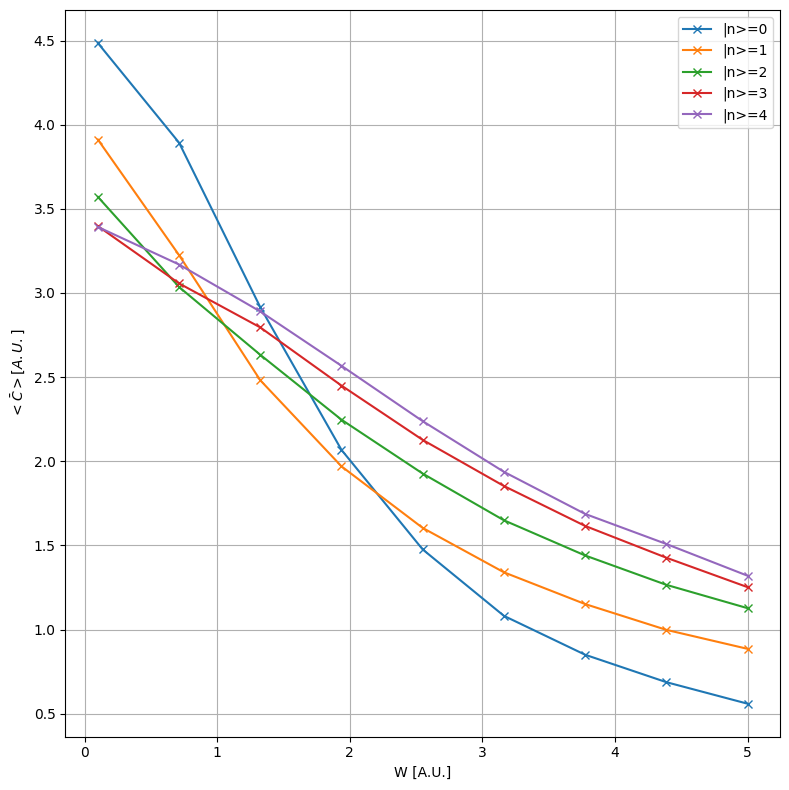

In [18]:
fig, axx = plt.subplots(1,1, figsize=(8,8), tight_layout=True)

for i in range(i_max):
    axx.plot(disorders, averages[i], marker="x", label=f"|n>={i}")
axx.set_xlabel("W [A.U.]")
axx.set_ylabel(r"$<\bar{C}> [A.U.]$")
axx.grid(True)
axx.legend()

For small $W$, states localized at the edge of the chain have a higher complexity, likely because the Krylov base is larger; however, when the disorder, and thus the localization of eigenstates, is incremented, the opposite happens: states localized at the edge are apparently closer to being eigenvectors, so their overall complexity is lower.